In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, NodeRFModel

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  ,
    prediction_mode='classification'
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

sd = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()


rf = NodeRFModel(sd,verbose = 2)
rf.set_global_hparams(loss = 'rmse')
rf.set_model_hparams(class_weight = 'balanced', n_estimators=150, max_depth=10)
rf.train()
rf.forecast()

ps = PersistenceModel(sd)
ps.forecast()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23281373/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(



==                 noderfmodel                  ==
global_hparams_set ✓
model_hparams_set ✓
Training metrics for horizon 0: Accuracy = 0.8532, F1 = 0.1473
Validation metrics for horizon 0: Accuracy = 0.8504, F1 = 0.1027
trained ✓
forecasted ✓


PersistenceModel(name='persistence_model')

In [16]:
from src.models import ClimateologyModel

cm = ClimateologyModel(sd)
cm.forecast()

ClimateologyModel(name='climateology_model')

## Classification - evaluation

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:10<00:00,  1.55s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

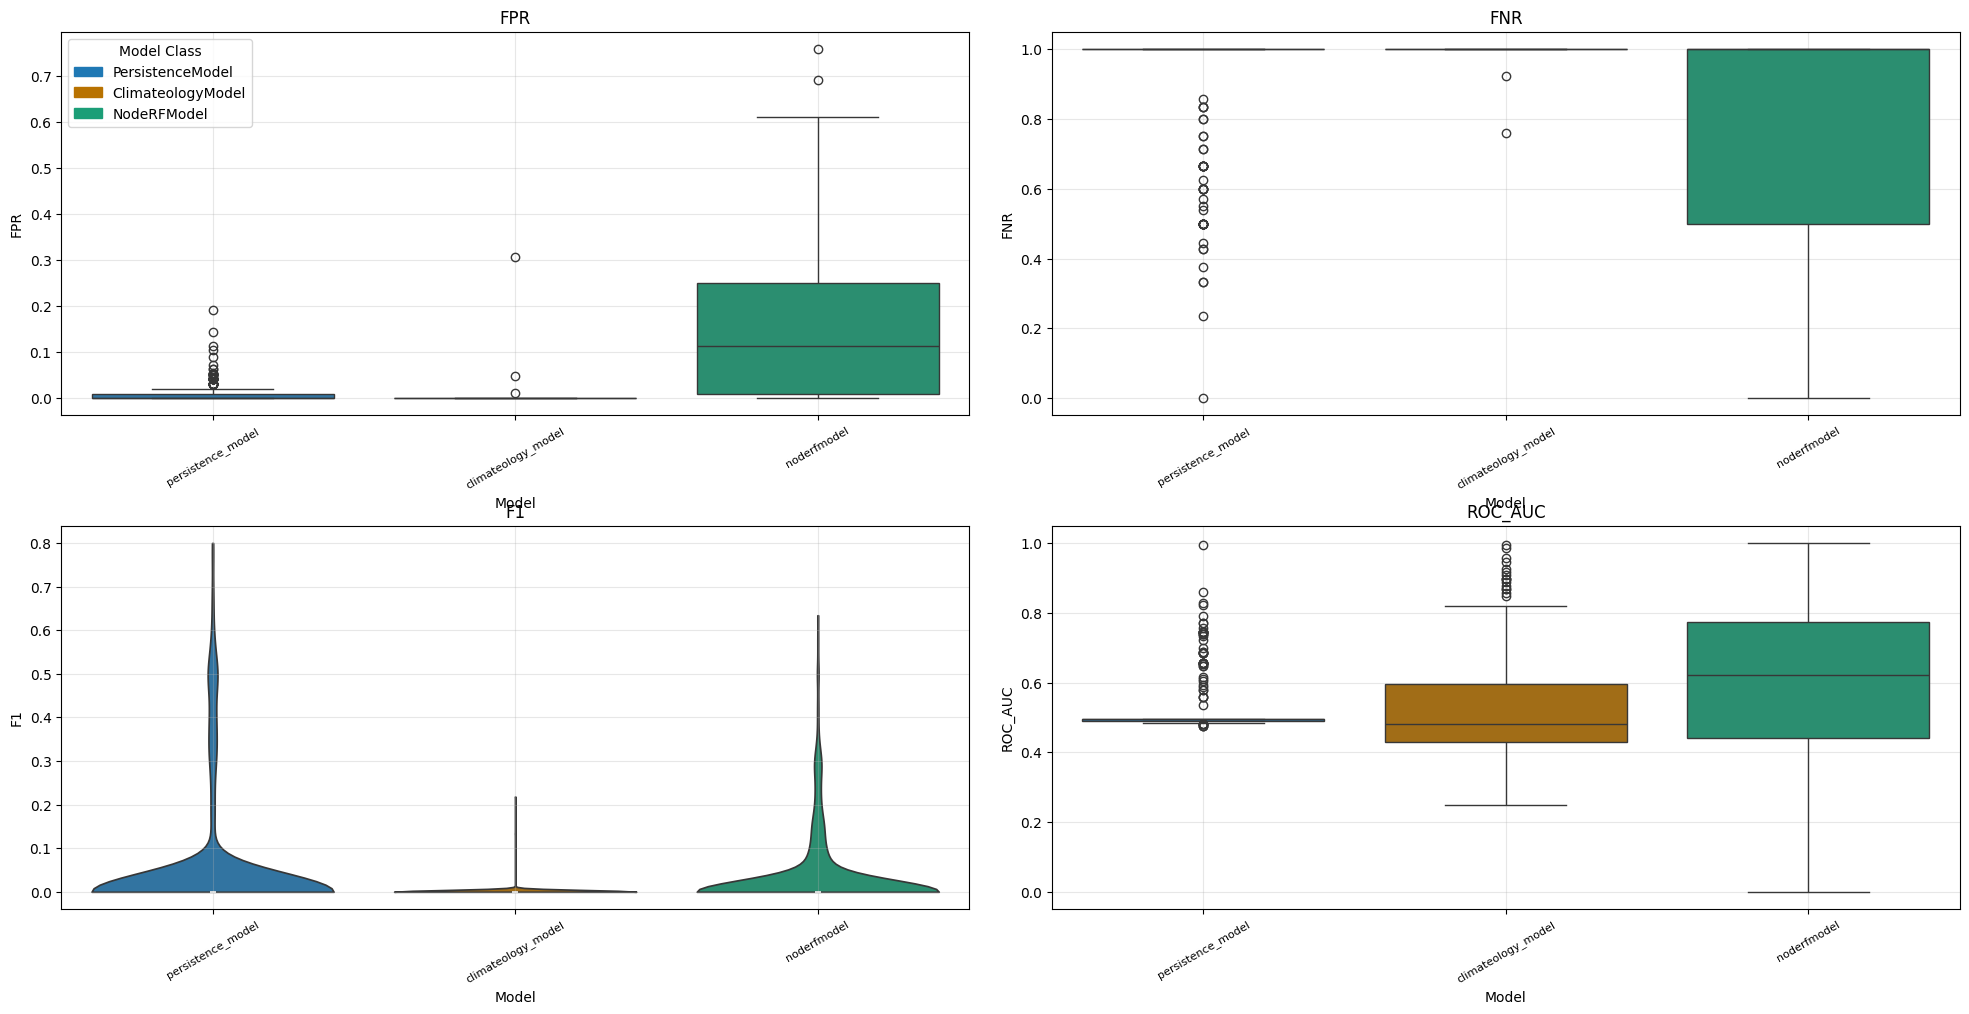

In [17]:
from src.evaluation import Evaluator
classification_evaluator = Evaluator(models = [ps, cm, rf]).add_evaluation()
classification_evaluator.plotter.plot_metric_compilation(metrics = ['fpr','fnr','f1','roc_auc']).change_figsize(20,10).show()

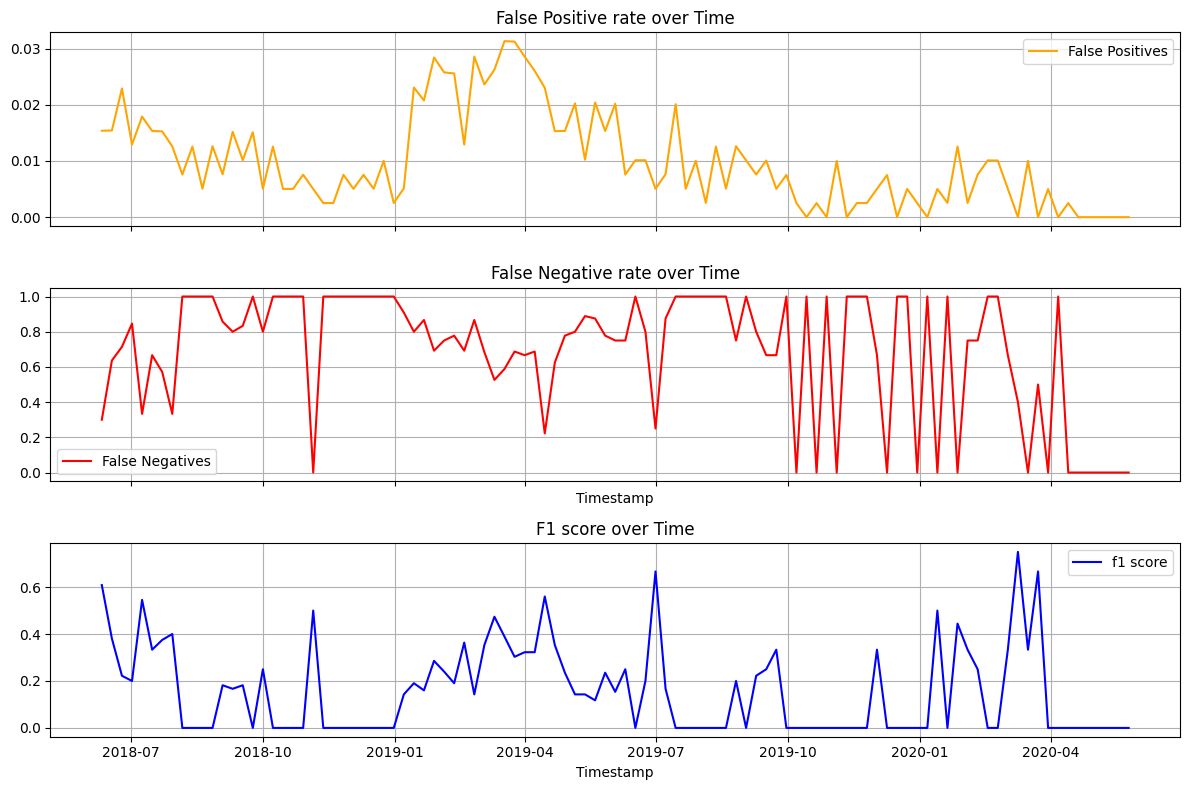

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['FPR'], label='False Positives', color='orange')
# axes[0].set_ylabel('Count')
axes[0].set_title('False Positive rate over Time')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['FNR'], label='False Negatives', color='red')
# axes[1].set_ylabel('Count')
axes[1].set_xlabel('Timestamp')
axes[1].set_title('False Negative rate over Time')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['f1'], label='f1 score', color='blue')
# axes[2].set_ylabel('Count')
axes[2].set_xlabel('Timestamp')
axes[2].set_title('F1 score over Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

df = ps.predictions.test.get_original(0)

metrics_per_node = df.groupby('node').apply(
    lambda x: pd.Series({
        'f1': f1_score(x['target'], x['pred'], zero_division=0),
        'recall': recall_score(x['target'], x['pred'], zero_division=0),
        'precision': precision_score(x['target'], x['pred'], zero_division=0),
        'accuracy': accuracy_score(x['target'], x['pred']),
        'FP_count': ((x['pred'] == 1) & (x['target'] == 0)).sum(),
        'FN_count': ((x['pred'] == 0) & (x['target'] == 1)).sum(),
        'TP_count': ((x['pred'] == 1) & (x['target'] == 1)).sum(),
        'TN_count': ((x['pred'] == 0) & (x['target'] == 0)).sum(),
        'total_actual_positives': (x['target'] == 1).sum(),
        'total_actual_negatives': (x['target'] == 0).sum()
    })
).reset_index()

# Calculate rates
metrics_per_node['FPR'] = metrics_per_node['FP_count'] / metrics_per_node['total_actual_negatives']
metrics_per_node['FNR'] = metrics_per_node['FN_count'] / metrics_per_node['total_actual_positives']

metrics_per_node['FPR'] = metrics_per_node['FPR'].fillna(0)
metrics_per_node['FNR'] = metrics_per_node['FNR'].fillna(0)

print(metrics_per_node[['node', 'f1', 'recall', 'precision', 'total_actual_positives']])

     node   f1  recall  precision  total_actual_positives
0       0  0.0     0.0        0.0                     1.0
1       1  0.0     0.0        0.0                     0.0
2       2  0.0     0.0        0.0                     1.0
3       3  0.0     0.0        0.0                     0.0
4       4  0.0     0.0        0.0                     1.0
..    ...  ...     ...        ...                     ...
395   395  0.0     0.0        0.0                     0.0
396   396  0.0     0.0        0.0                     0.0
397   397  0.0     0.0        0.0                     0.0
398   398  0.0     0.0        0.0                     0.0
399   399  0.0     0.0        0.0                     0.0

[400 rows x 5 columns]


/local/job_23281373/ipykernel_166120/2374985611.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_per_node = df.groupby('node').apply(


     node   f1  recall  precision  total_actual_positives
0       0  0.0     0.0        0.0                     1.0
1       1  0.0     0.0        0.0                     0.0
2       2  0.0     0.0        0.0                     1.0
3       3  0.0     0.0        0.0                     0.0
4       4  0.0     0.0        0.0                     1.0
..    ...  ...     ...        ...                     ...
395   395  0.0     0.0        0.0                     0.0
396   396  0.0     0.0        0.0                     0.0
397   397  0.0     0.0        0.0                     0.0
398   398  0.0     0.0        0.0                     0.0
399   399  0.0     0.0        0.0                     0.0

[400 rows x 5 columns]


/local/job_23281373/ipykernel_166120/2573943710.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_per_node = df.groupby('node').apply(
/local/job_23281373/ipykernel_166120/2573943710.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


[Text(0, 0, '')]

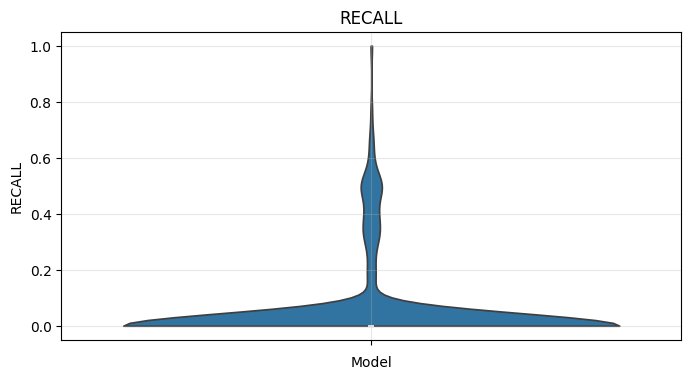

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

df = ps.predictions.test.get_original(0)

metrics_per_node = df.groupby('node').apply(
    lambda x: pd.Series({
        'f1': f1_score(x['target'], x['pred'], zero_division=0),
        'recall': recall_score(x['target'], x['pred'], zero_division=0),
        'precision': precision_score(x['target'], x['pred'], zero_division=0),
        'accuracy': accuracy_score(x['target'], x['pred']),
        'FP_count': ((x['pred'] == 1) & (x['target'] == 0)).sum(),
        'FN_count': ((x['pred'] == 0) & (x['target'] == 1)).sum(),
        'TP_count': ((x['pred'] == 1) & (x['target'] == 1)).sum(),
        'TN_count': ((x['pred'] == 0) & (x['target'] == 0)).sum(),
        'total_actual_positives': (x['target'] == 1).sum(),
        'total_actual_negatives': (x['target'] == 0).sum()
    })
).reset_index()

# Calculate rates
metrics_per_node['FPR'] = metrics_per_node['FP_count'] / metrics_per_node['total_actual_negatives']
metrics_per_node['FNR'] = metrics_per_node['FN_count'] / metrics_per_node['total_actual_positives']

metrics_per_node['FPR'] = metrics_per_node['FPR'].fillna(0)
metrics_per_node['FNR'] = metrics_per_node['FNR'].fillna(0)

print(metrics_per_node[['node', 'f1', 'recall', 'precision', 'total_actual_positives']])

plot_type = 'violin'
fig, ax = plt.subplots(1,1,figsize= (8,4))
metric = 'recall'

plot_func = sns.violinplot if plot_type == 'violin' else sns.boxplot
plot_func(
    data=metrics_per_node, y=metric,
    ax=ax,
    **(dict(cut=0) if plot_type == 'violin' else {}),
    legend=False
)

ax.set_title(f'{metric.upper()}')
ax.set_ylabel(metric.upper())
ax.set_xlabel('Model')
ax.grid(alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


## DeepLoader

In [ ]:
deepdata = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()